# Cycle 7 : Approche finale


In [100]:
### Import des modules
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import utils
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from technova_correlation_cleaning import CorrelationFilter
from technova_features import TechNovaFeatureEngineering

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
data = pd.read_csv('data/rafined/employees.csv', sep=',')

In [102]:
train_data = utils.split_train_data(data, 'a_quitte_l_entreprise')

In [103]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

numeric_features = data.select_dtypes(include=['int64', 'float64'])
categorical_features = ['statut_marital', 'departement', 'poste', 'domaine_etude']

preprocessor = ColumnTransformer(
    transformers=[
        ('standard_scaler', StandardScaler(), make_column_selector(dtype_include='number')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include='object')),
    ],
    remainder='drop'
)

In [104]:
nb_features_to_keep = 15

In [105]:
from sklearn.feature_selection import SelectFromModel
import numpy as np

feature_selector = SelectFromModel(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    max_features=nb_features_to_keep,
    threshold=-np.inf
)

final_model = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=15,
    random_state=42
)

In [106]:
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(random_state=42, max_iter=5000, class_weight='balanced')

threshold_model = FixedThresholdClassifier(
    estimator=logistic_regression_model,
    threshold=0.5,
    response_method="predict_proba"
)

pipeline = Pipeline([
    ('features', TechNovaFeatureEngineering()),
    ('corr_cleaning', CorrelationFilter(threshold=0.80)),
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('model', threshold_model),
])

utils.benchmark(pipeline, train_data)

--- Validation Fold Results ---
Validation Recall : [0.65789474 0.84210526 0.68421053 0.65789474 0.81578947], Recall moyen : 0.7315789473684211
Validation F1-Scores [0.43478261 0.47058824 0.47706422 0.4587156  0.55357143], F1 moyen : 0.4789444178149919
Validation ROC AUC : [0.69790005 0.84517766 0.81218274 0.75434144 0.85359337], ROC moyen : 0.7926390541805983

--- Train Fold Results (Overfit Check) ---
Train Recall : [0.79605263 0.72368421 0.78289474 0.73684211 0.71052632], Recall moyen : 0.75
Train F1-Scores [0.53658537 0.47722343 0.52422907 0.4838013  0.46551724], F1 moyen : 0.4974712810702105
Train ROC AUC : [0.85243287 0.81298779 0.82761323 0.82380261 0.80198953], ROC moyen : 0.8237652087868627


Meilleurs paramètres : {'model__estimator__C': np.float64(0.010051981180656781), 'model__estimator__l1_ratio': np.float64(0.14286681792194078), 'model__estimator__solver': 'saga', 'model__threshold': 0.5}
f1 moyen en Validation Croisée : 0.6073

--- Validation Fold Results ---
Validation Recall : [0.63157895 0.84210526 0.73684211 0.60526316 0.84210526], Recall moyen : 0.731578947368421
Validation F1-Scores [0.44036697 0.48484848 0.50909091 0.42592593 0.56637168], F1 moyen : 0.4853207947516626
Validation ROC AUC : [0.6920521  0.84985306 0.8232701  0.74993321 0.85586428], ROC moyen : 0.7941945503660705

--- Train Fold Results (Overfit Check) ---
Train Recall : [0.77631579 0.70394737 0.75       0.71710526 0.71052632], Recall moyen : 0.7315789473684211
Train F1-Scores [0.52212389 0.46521739 0.51006711 0.47807018 0.46753247], F1 moyen : 0.4886022084349363
Train ROC AUC : [0.84779923 0.80028017 0.81744046 0.81664832 0.79472684], ROC moyen : 0.8153790032056459
Vérif overfit
ROC AUC - Train Se

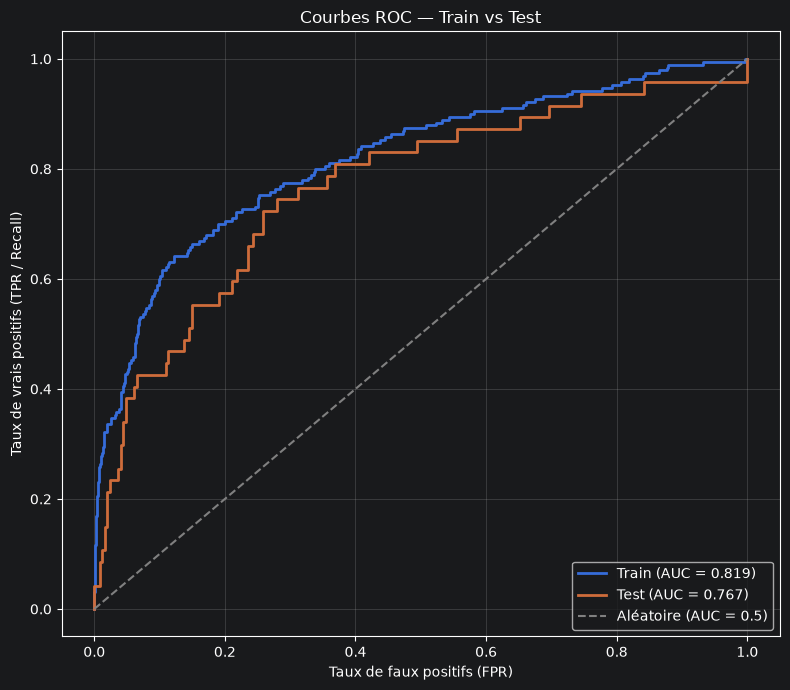

In [118]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score, roc_auc_score, classification_report, make_scorer, \
    fbeta_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_distributions = {
    'model__estimator__solver': ['saga'],
    'model__estimator__C': loguniform(1e-4, 1e2),
    'model__estimator__l1_ratio': uniform(0, 1),
    'model__threshold': [0.3, 0.4, 0.5, 0.6],
}

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=f2_scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

search.fit(train_data['X_train'], train_data['y_train'])

print(f"Meilleurs paramètres : {search.best_params_}")
print(f"f1 moyen en Validation Croisée : {search.best_score_:.4f}\n")

best_pipeline = search.best_estimator_

utils.benchmark(best_pipeline, train_data)

y_pred_test = best_pipeline.predict(train_data['X_test'])
y_probs_test = best_pipeline.predict_proba(train_data['X_test'])[:, 1]
y_pred_test = best_pipeline.predict(train_data['X_test'])

y_probs_train = best_pipeline.predict_proba(train_data['X_train'])[:, 1]
y_pred_train = best_pipeline.predict(train_data['X_train'])

auc_train = roc_auc_score(train_data['y_train'], y_probs_train)
auc_test = roc_auc_score(train_data['y_test'], y_probs_test)

recall_train = recall_score(train_data['y_train'], y_pred_train)
recall_test = recall_score(train_data['y_test'], y_pred_test)

f1_train = f1_score(train_data['y_train'], y_pred_train)
f1_test = f1_score(train_data['y_test'], y_pred_test)

print("Vérif overfit")
print(f"ROC AUC - Train Set : {auc_train:.4f}")
print(f"ROC AUC - Test Set  : {auc_test:.4f}")
print(f"Différence ROC AUC (Overfit) : {auc_train - auc_test:.4f}\n")
print(f"Recall - Train Set : {recall_train:.4f}")
print(f"Recall - Test Set  : {recall_test:.4f}")
print(f"Différence Recall (Overfit) : {recall_train - recall_test:.4f}\n")
print(f"f1 - Train Set : {f1_train:.4f}")
print(f"f1 - Test Set  : {f1_test:.4f}")
print(f"Différence f1 (Overfit) : {f1_train - f1_test:.4f}\n")

print("Performances")
print(classification_report(train_data['y_test'], y_pred_test))

print("Matrice de Confusion :")
print(confusion_matrix(train_data['y_test'], y_pred_test))

from sklearn.metrics import roc_curve

fpr_train, tpr_train, _ = roc_curve(train_data['y_train'], y_probs_train)
fpr_test, tpr_test, _ = roc_curve(train_data['y_test'], y_probs_test)

plt.figure(figsize=(8, 7))

plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})", linewidth=2)
plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {auc_test:.3f})", linewidth=2)

# Diagonale = classifieur aléatoire (AUC 0.5)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label="Aléatoire (AUC = 0.5)")

plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR / Recall)")
plt.title("Courbes ROC — Train vs Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

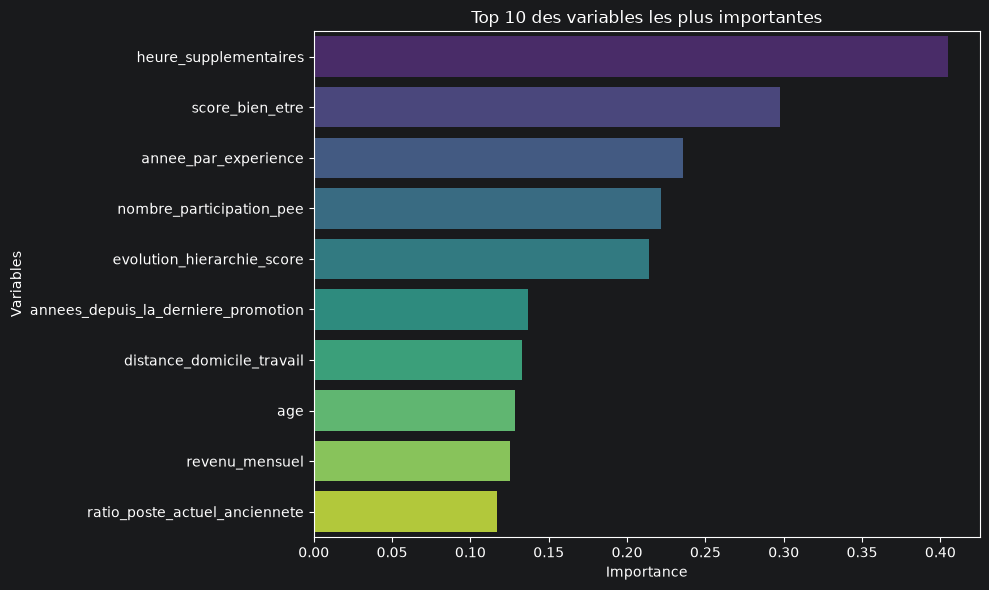

In [120]:
model_fitted = best_pipeline.named_steps['model'].estimator_
importances = np.abs(model_fitted.coef_[0])

# noms en sortie du preprocessor (toutes les features)
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
names_all = preprocessor_fitted.get_feature_names_out()

# masque des features retenues par SelectFromModel
selector = best_pipeline.named_steps['feature_selection']
names = names_all[selector.get_support()]

feature_names = [
    name.replace('standard_scaler__', '')
        .replace('encoder__', '')
        .replace('remainder__', '')
    for name in names
]


utils.show_importances(importances, feature_names, 10)

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.


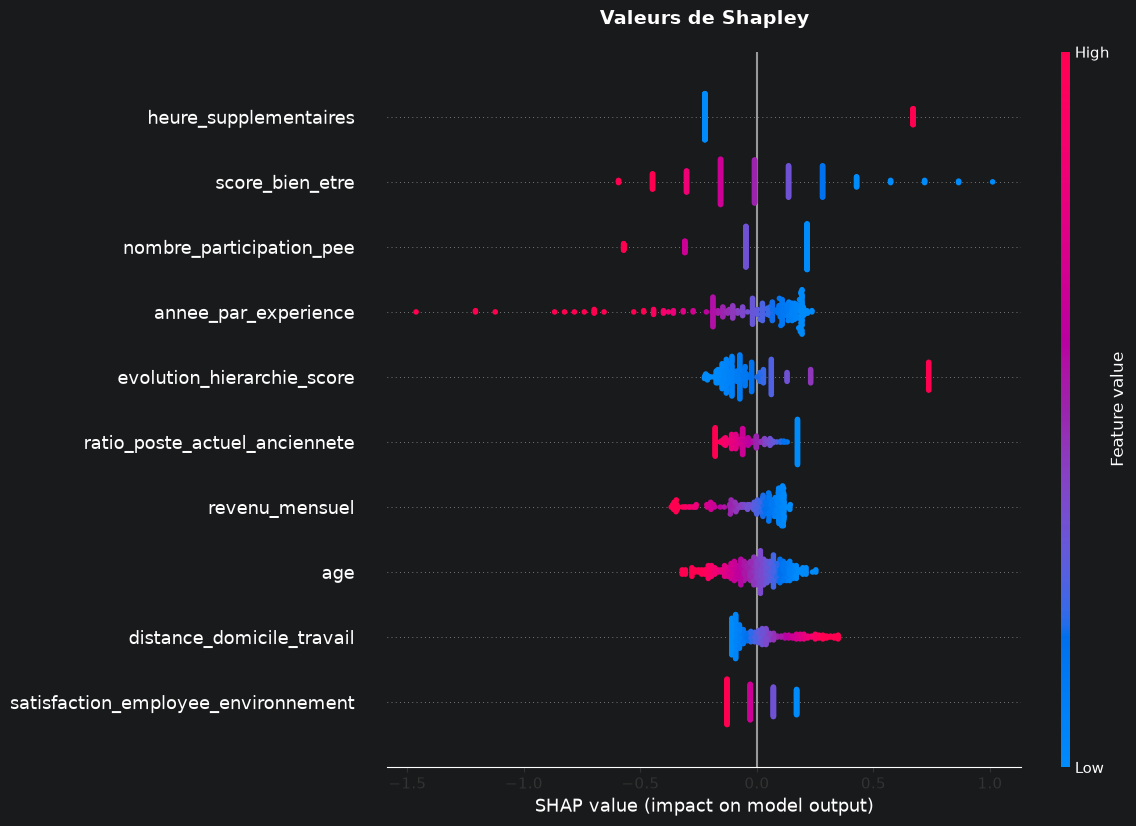

In [122]:
import shap

prep_pipeline = Pipeline(best_pipeline.steps[:-1])

# noms après le preprocessor (toutes les features)
names_all = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# masque du feature_selection → garder seulement les features retenues
selector = best_pipeline.named_steps['feature_selection']
feature_names = names_all[selector.get_support()]

# nettoyage des préfixes
feature_names = [
    name.replace('standard_scaler__', '')
        .replace('encoder__', '')
        .replace('remainder__', '')
    for name in feature_names
]

X_test_shap = pd.DataFrame(
    prep_pipeline.transform(train_data['X_test']),
    columns=feature_names
)

final_model = best_pipeline.named_steps['model'].estimator_

explainer = shap.LinearExplainer(final_model, X_test_shap)
shap_values = explainer.shap_values(X_test_shap)

shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=10,
    plot_type="dot",
    plot_size=(12, 8),
    show=False
)

ax = plt.gca()

# labels de l'axe Y = noms des features
ax.tick_params(axis='y', colors='white')

# par sécurité, forcer aussi chaque label individuellement
for label in ax.get_yticklabels():
    label.set_color('white')

plt.title("Valeurs de Shapley", fontsize=14, fontweight='bold', pad=20)
plt.show()